# 9. Scaling up, and correcting across laboratories

At screen scale, data often no longer fits in memory and comes from more than one
laboratory. This page covers both, using JUMP-Target-2, the plate the JUMP consortium {cite:p}`Chandrasekaran_2023` ran at
every participating laboratory, so any difference between two copies of it is technical.

A note on terms. JUMP calls a participating laboratory a source, and this page uses that
column throughout: `Metadata_Source`, with values `source_3` and `source_4`. In a
CellProfiler export, `Metadata_Site` is a field of view inside a well (four or nine per well),
which this page does not use. When this page says "site", it means the laboratory.

The correction results at the end differ from what the batch metrics predict.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import mantispy as mt

## Working from disk

`mt.io.read(path, backed="r")` leaves `X` in the file. `obs` and `var` are loaded into
memory, so metadata, QC flags and feature selection work as before, and grouped operations
read one group at a time.

On 100 000 cells by 500 features, a per-plate median takes 3.5 s and 44 MB backed, against
0.8 s and a 200 MB resident matrix in memory: four times the runtime for four and a half times
less memory. Use it only on data that does not fit in memory.

In [2]:
plate = mt.ds.synthetic_plate(n_plates=4, n_wells=96, n_cells=40, n_features=40, seed=0)
mt.io.write(plate, "scaling_demo.h5ad")

backed = mt.io.read("scaling_demo.h5ad", backed="r")
in_memory = mt.io.read("scaling_demo.h5ad")

{
    "backed": (backed.isbacked, type(backed.X).__name__),
    "in memory": (in_memory.isbacked, type(in_memory.X).__name__),
    "obs is in memory either way": type(backed.obs).__name__,
}

{'backed': (True, 'Dataset'),
 'in memory': (False, 'ndarray'),
 'obs is in memory either way': 'DataFrame'}

In [3]:
from_disk = mt.pp.normalize(backed, by="Metadata_Plate", reference="negcon", copy=True)
resident = mt.pp.normalize(in_memory, by="Metadata_Plate", reference="negcon", copy=True)

{
    "identical": bool(np.allclose(np.asarray(from_disk.X), np.asarray(resident.X), rtol=1e-6)),
    "largest difference": float(np.abs(np.asarray(from_disk.X) - np.asarray(resident.X)).max()),
}

{'identical': True, 'largest difference': 0.0}

The results are identical. The backed path reduces group by group while the in-memory path
makes one kernel call, and the test suite asserts they agree to 1e-10.

Functions that rewrite `X` need `copy=True` here. The file is open read-only, so they raise a
clear error instead of failing inside h5py:

In [4]:
try:
    mt.pp.normalize(backed, by="Metadata_Plate")
except ValueError as error:
    print(error)

normalize rewrites X, which a backed object holds read-only on disk. Pass copy=True to get the result in memory, or call adata.to_memory() first.


## JUMP-Target-2

`mt.ds.jump_target2()` downloads two TARGET2 plates, one from each of two sources, and joins
the JUMP annotation onto them. The plate map is identical at both sources; only the
laboratory differs.

In [5]:
jump = mt.ds.jump_target2()
{
    "shape": jump.shape,
    "sources": jump.obs["Metadata_Source"].value_counts().to_dict(),
    "perturbations": int(jump.obs["Metadata_Perturbation"].nunique()),
    "control wells": int(jump.obs["Metadata_Control"].sum()),
}

/Users/tim.treis/Documents/GitHub/mantispy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'shape': (768, 3634),
 'sources': {'source_3': 384, 'source_4': 384},
 'perturbations': 302,
 'control wells': 128}

A JUMP plate parquet has three metadata columns (source, plate and well) and no information
about what each well contained. `mt.pp.annotate_jump`, which `read_jump` calls, joins the
perturbation identity from the JUMP metadata repository.

## The same pipeline

The recipe does not change for data from two sites, including the `degenerate_scale` drop
from [tutorial 6](06_mechanism_of_action.ipynb). That drop matters most here: 65 of JUMP's
features have no spread among the control wells of some plate, and `mad_robustize` would
return each of them at around 1e17.

In [6]:
mt.pp.normalize(jump, method="mad_robustize", by="Metadata_Plate", reference="negcon")
degenerate = int(jump.var["degenerate_scale"].sum())
jump = jump[:, ~jump.var["degenerate_scale"].to_numpy()].copy()
mt.pp.feature_select(jump, na_cutoff=0.0)
jump = mt.pp.subset_features(jump)

{
    "features with no spread among the controls": degenerate,
    "features kept": jump.n_vars,
    "control wells per source": jump.obs.groupby("Metadata_Source", observed=True)["Metadata_Control"].sum().to_dict(),
}

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_30941/2171000468.py:1: UserWarning: 65 of 3634 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy(). Feature selection does not catch a feature that varies across a plate but is constant among its control wells.
  mt.pp.normalize(jump, method="mad_robustize", by="Metadata_Plate", reference="negcon")


{'features with no spread among the controls': 65,
 'features kept': 480,
 'control wells per source': {'source_3': 64, 'source_4': 64}}

## How big is the site effect?

`mt.metrics.evaluate_correction` runs the batch metrics and says which direction is better
for each.

In [7]:
sc.pp.pca(jump, n_comps=30)
mt.metrics.evaluate_correction(jump, label_key="Metadata_Perturbation", batch_key="Metadata_Source").round(3)

,metric,representation,key,value,better
0,silhouette_label,X_pca,Metadata_Perturbation,0.324,higher
1,silhouette_batch,X_pca,Metadata_Source,0.521,higher
2,ilisi,X_pca,Metadata_Source,1.605,higher
3,clisi,X_pca,Metadata_Perturbation,8.164,lower
4,pc_regression,X_pca,Metadata_Source,0.020,lower


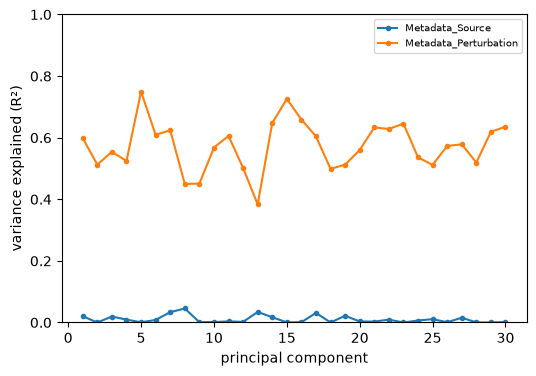

In [8]:
ax = mt.pl.batch_variance(jump, keys=["Metadata_Source", "Metadata_Perturbation"])
plt.show()

## Cross-source retrieval

Batch metrics ask whether the sites mix. A screen needs to know whether the same compound, run
at two sites, produces the same profile. That is a retrieval task, with `pos_sameby` set to the
perturbation and `pos_diffby` to the source.

The next cell computes the baseline and four corrections.

In [9]:
def cross_source_map(adata, use_rep=None):
    """Mean average precision for retrieving a compound across sites."""
    treated = adata[~adata.obs["Metadata_Control"].to_numpy()].copy()
    mt.tl.map(
        treated,
        pos_sameby=["Metadata_Perturbation"],
        pos_diffby=["Metadata_Source"],
        neg_diffby=["Metadata_Perturbation"],
        use_rep=use_rep,
        null_size=500,
        seed=0,
    )
    table = treated.uns["mantispy"]["map"]
    return round(float(table["mean_average_precision"].mean()), 3), int(table["below_corrected_p"].sum())


n_treated = int(jump.obs.loc[~jump.obs["Metadata_Control"].to_numpy(), "Metadata_Perturbation"].nunique())
variants = {"per-plate normalize only": jump}

per_source = jump.copy()
mt.pp.sphere(per_source, method="ZCA-cor", reference="negcon", by="Metadata_Source")
variants["+ sphere per source"] = per_source

pooled = jump.copy()
mt.pp.sphere(pooled, method="ZCA-cor", reference="negcon")
variants["+ sphere pooled controls"] = pooled

regressed = jump.copy()
mt.pp.regress_out(regressed, keys=["Metadata_Source"], by=None)
variants["+ regress out source"] = regressed

reproducible = jump.copy()
mt.pp.feature_reproducibility(reproducible, groupby="Metadata_Perturbation", min_icc=0.2)
reproducible = reproducible[:, reproducible.var["icc_selected"].to_numpy()].copy()
variants["+ keep ICC > 0.2"] = reproducible

pd.DataFrame(
    [
        {"pipeline": name, "features": adata.n_vars, "cross-source mAP": score, f"significant of {n_treated}": count}
        for name, adata in variants.items()
        for score, count in [cross_source_map(adata)]
    ]
)

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_30941/2805155733.py:21: UserWarning: sphering is fitted on 64 reference rows for 480 features. With fewer rows than features the covariance is singular and the transform amplifies noise (on BBBC021 it lowered not-same-compound MOA retrieval from 78% to 22%). Select fewer features first, or use more controls.
  mt.pp.sphere(per_source, method="ZCA-cor", reference="negcon", by="Metadata_Source")
/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_30941/2805155733.py:25: UserWarning: sphering is fitted on 128 reference rows for 480 features. With fewer rows than features the covariance is singular and the transform amplifies noise (on BBBC021 it lowered not-same-compound MOA retrieval from 78% to 22%). Select fewer features first, or use more controls.
  mt.pp.sphere(pooled, method="ZCA-cor", reference="negcon")


,pipeline,features,cross-source mAP,significant of 301
0,per-plate normalize only,480,0.086,31
1,+ sphere per source,480,0.029,0
2,+ sphere pooled controls,480,0.039,0
3,+ regress out source,480,0.005,0
4,+ keep ICC > 0.2,422,0.094,33


In [10]:
# The batch metrics again, on the sphering that cost the most retrieval.
sphered = variants["+ sphere per source"].copy()
sc.pp.pca(sphered, n_comps=30)
mt.metrics.evaluate_correction(
    sphered, reps=("X_pca",), label_key="Metadata_Perturbation", batch_key="Metadata_Source"
).round(3)

,metric,representation,key,value,better
0,silhouette_label,X_pca,Metadata_Perturbation,0.397,higher
1,silhouette_batch,X_pca,Metadata_Source,0.501,higher
2,ilisi,X_pca,Metadata_Source,1.693,higher
3,clisi,X_pca,Metadata_Perturbation,3.362,lower
4,pc_regression,X_pca,Metadata_Source,0.003,lower


Compare that table with the metrics above.

Per-source sphering improves almost every batch metric. The sites mix better (iLISI 1.605
to 1.693), the labels separate better (cLISI 8.164 to 3.362, label silhouette 0.324 to
0.397), and the variance explained by source drops from 0.020 to 0.003. Only the batch
silhouette moves the wrong way, from 0.521 to 0.501.

It also reduces cross-source retrieval from 0.086 to 0.029, and the number of compounds
recovered above chance drops from 31 to zero. Pooled sphering and regressing out the source
have the same effect.

The only row that does not hurt is keeping the features whose replicates agree, which is not a
batch correction, and its gain is small: 0.086 to 0.094, two more compounds. None of the rows
in this table fixes the site effect; a step that helps follows later on this page.

Batch correction can still be useful, but it should not be judged by how well the batches mix,
which is what every metric in the first table measures. Removing signal makes batches mix
easily.

With two plates, there are 64 control wells per site against 480 features, so every
covariance-based correction here is underdetermined. With twenty plates per site the result
could differ. `evaluate_correction` accepts a `map_key` so that the retrieval number appears
in the same table as the mixing metrics.

## What the consortium's recipe does

JUMP has three recipes, and the perturbation type decides which one applies.
`jump-profiling-recipe` names them in its configs. For compounds, which TARGET-2 contains,
`compound.json` specifies

```
profiles_var_mad_int_featselect_harmony
```

that is, variance-based feature selection, MAD normalization against the negative controls, the rank
inverse normal transform, feature selection and Harmony. The ORF and CRISPR branches use a
different pipeline, `profiles_wellpos_cc_var_mad_outlier_featselect_sphering_harmony`, which
adds well position correction, cell count regression, outlier removal and sphering.

Sphering is not in the compound pipeline, and on these compound plates it was the step that
cut retrieval the most. The two steps of the compound pipeline that the comparison above does
not include are covered below, and both behave differently from the corrections in that table.

`pp.rank_int` is the rank inverse normal transform. Each feature's values are replaced by
their normal scores within a plate, so only the ordering of the wells is kept and the scale is
discarded. Every feature ends up standard normal by construction, which is a strong assumption
about your data, so check what it costs.

In [11]:
inted = jump.copy()
mt.pp.rank_int(inted, by="Metadata_Plate")

# The reference implementation ranks each feature over the whole screen; ranking within a
# plate additionally removes any plate-level difference in the shape of the distribution.
globally = jump.copy()
mt.pp.rank_int(globally)

inted_icc = inted.copy()
mt.pp.feature_reproducibility(inted_icc, groupby="Metadata_Perturbation", min_icc=0.2)
inted_icc = inted_icc[:, inted_icc.var["icc_selected"].to_numpy()].copy()

pd.DataFrame(
    [
        {"pipeline": name, "features": adata.n_vars, "cross-source mAP": score, f"significant of {n_treated}": count}
        for name, adata in [
            ("per-plate normalize only", jump),
            ("+ rank INT, ranked globally", globally),
            ("+ rank INT, ranked per plate", inted),
            ("+ rank INT per plate, then ICC > 0.2", inted_icc),
        ]
        for score, count in [cross_source_map(adata)]
    ]
)

,pipeline,features,cross-source mAP,significant of 301
0,per-plate normalize only,480,0.086,31
1,"+ rank INT, ranked globally",480,0.106,65
2,"+ rank INT, ranked per plate",480,0.142,80
3,"+ rank INT per plate, then ICC > 0.2",441,0.158,82


This is the first step on this page that helps. Cross-source retrieval more than doubles the
number of compounds recovered above chance, and adding the ICC filter improves it a little
more. Sphering removed the site effect together with the biology; ranking removes only the
scale, which is where most of the site difference was.

Where you rank matters. The reference implementation ranks each feature over the whole
screen, which is the `by=None` default. Ranking within each plate works markedly better here,
because it also removes plate-to-plate differences in the shape of a feature's distribution,
which partly separate the two sites.

Where INT sits in the pipeline matters much less. The recipe applies it before feature
selection, and this notebook applies it after. The other order (measured separately, not in
the table above) gives 0.137 with 85 compounds above chance, against 0.142 and 80 in the
table, on 627 features instead of 480. The feature count differs because INT makes every
feature standard normal, so a variance threshold has nothing left to discriminate on and drops
far fewer features.

The transform discards magnitude, and distance from the controls depends on magnitude, so
check the effect on activity as well:

In [12]:
def activity(adata):
    """Phenotypic activity: can each compound be told from the negative controls?"""
    scratch = adata.copy()
    mt.tl.map(scratch, mode="activity", null_size=500, seed=0)
    table = scratch.uns["mantispy"]["map"]
    return round(float(table["mean_average_precision"].mean()), 3), int(table["below_corrected_p"].sum())


{"per-plate normalize only": activity(jump), "+ rank INT": activity(inted)}

{'per-plate normalize only': (0.232, 46), '+ rank INT': (0.306, 68)}

Here it costs nothing, and activity rises too. That does not generalize: this is two sources
and 480 features. On the full 132-plate set, where there are enough controls for the raw
magnitudes to be meaningful, the transform lowers activity in exchange for comparability. The
outcome depends on the screen, so measure both before adopting it.

## Harmony, and a metric that disagrees with retrieval

`pp.harmony` is the best-performing method in the benchmark and the last step of the recipe.
It works on an embedding rather than on features (it alternates soft clustering and
per-cluster linear correction), so it returns a corrected `obsm`, not a corrected `X`.

In [13]:
harmonised = jump.copy()
sc.pp.pca(harmonised, n_comps=30)
mt.pp.harmony(harmonised, batch_key="Metadata_Source", use_rep="X_pca")

mt.metrics.evaluate_correction(
    harmonised, reps=("X_pca", "X_harmony"), label_key="Metadata_Perturbation", batch_key="Metadata_Source"
).round(3)

,metric,representation,key,value,better
0,silhouette_label,X_pca,Metadata_Perturbation,0.324,higher
1,silhouette_batch,X_pca,Metadata_Source,0.521,higher
2,ilisi,X_pca,Metadata_Source,1.605,higher
3,clisi,X_pca,Metadata_Perturbation,8.165,lower
4,pc_regression,X_pca,Metadata_Source,0.020,lower
5,silhouette_label,X_harmony,Metadata_Perturbation,0.332,higher
6,silhouette_batch,X_harmony,Metadata_Source,0.541,higher
7,ilisi,X_harmony,Metadata_Source,1.500,higher
8,clisi,X_harmony,Metadata_Perturbation,8.285,lower
9,pc_regression,X_harmony,Metadata_Source,0.016,lower


In [14]:
# The two site centroids, and the retrieval, before and after.
sources = harmonised.obs["Metadata_Source"].astype(str).to_numpy()
{
    key: {
        "site centroid distance": round(
            float(
                np.linalg.norm(
                    harmonised.obsm[key][sources == "source_3"].mean(axis=0)
                    - harmonised.obsm[key][sources == "source_4"].mean(axis=0)
                )
            ),
            1,
        ),
        "cross-source mAP": cross_source_map(harmonised, use_rep=key),
    }
    for key in ("X_pca", "X_harmony")
}

{'X_pca': {'site centroid distance': 436.6, 'cross-source mAP': (0.085, 32)},
 'X_harmony': {'site centroid distance': 371.9, 'cross-source mAP': (0.1, 62)}}

Harmony moves the two sites 15% closer and raises cross-source retrieval from 0.085 to 0.100,
nearly doubling the compounds recovered above chance. iLISI, however, gets worse, from 1.605
to 1.500.

This is the same disagreement as with sphering, in the opposite direction. With sphering the
batch metrics improved while retrieval collapsed; here a batch metric gets worse while
retrieval improves. iLISI asks whether a well's nearest neighbors come from both sites.
Harmony aligns the sites globally without mixing local neighborhoods, so a well stays
surrounded by wells from its own site while the two clouds move together. Both observations
hold, and retrieval is the one that answers the screen's question.

harmonypy can report convergence and return the embedding unchanged. `pp.harmony` compares its
output with its input and warns when they are identical, so that uncorrected numbers do not
pass unnoticed through the rest of the pipeline.

In [15]:
treated = jump[~jump.obs["Metadata_Control"].to_numpy()].copy()
mt.tl.map(
    treated,
    pos_sameby=["Metadata_Perturbation"],
    pos_diffby=["Metadata_Source"],
    neg_diffby=["Metadata_Perturbation"],
    null_size=500,
    seed=0,
)
sc.pp.pca(treated, n_comps=30)
mt.metrics.evaluate_correction(
    treated, label_key="Metadata_Perturbation", batch_key="Metadata_Source", map_key="map"
).round(3)

,metric,representation,key,value,better
0,silhouette_label,X_pca,Metadata_Perturbation,0.339,higher
1,silhouette_batch,X_pca,Metadata_Source,0.511,higher
2,ilisi,X_pca,Metadata_Source,1.599,higher
3,clisi,X_pca,Metadata_Perturbation,12.930,lower
4,pc_regression,X_pca,Metadata_Source,0.024,lower
5,mean_average_precision,X,Metadata_Perturbation,0.086,higher


The last table is `evaluate_correction` with `map_key=` set, so the retrieval number appears
in the same table as the mixing metrics. Its `representation` reads `X`, the matrix `tl.map`
scored, not the `X_pca` of the rows above it. It runs on the treated wells only, which is why
cLISI reads 12.9 here against 8.2 in the first table on this page: dropping 128 DMSO wells
with the same label makes every neighborhood more label-diverse. Compare rows within a table, not
across tables built on different rows.


## Which compounds reproduce across sites?

The results above are aggregates: one mAP for the screen, one LISI per representation. Follow-up
work needs to know which compounds reproduced, which the page has not yet shown.

`tl.transport` answers that. It computes each perturbation's effect as its profile minus the
control centroid of its own setting, so a baseline offset does not count as disagreement, and
measures how well those effect vectors agree across settings. `by=` takes a list from coarsest
to finest level, and each pair of plates is assigned to the coarsest level at which the two
differ, so every comparison belongs to exactly one level.

This needs more than the two plates used so far. With one plate per laboratory, laboratory
and plate effects are the same comparison and cannot be separated. `jump_target2` pins twelve
plates: three sources, two batches each, two plates per batch. That adds a third source,
`source_6`, to the `source_3` and `source_4` introduced at the top.

This section uses only the per-plate `mad_robustize` normalization from earlier, without
`rank_int`, Harmony or the other corrections evaluated above. Its numbers are an uncorrected
baseline on a different set of plates and are not comparable with the two-plate mAP values
earlier on this page.

In [16]:
hierarchy = mt.ds.jump_target2(plates=None)
mt.pp.normalize(hierarchy, method="mad_robustize", by="Metadata_Plate", reference="negcon")
hierarchy = hierarchy[:, ~hierarchy.var["degenerate_scale"].to_numpy()].copy()
mt.pp.feature_select(hierarchy, na_cutoff=0.0)
hierarchy = mt.pp.subset_features(hierarchy)

mt.tl.transport(hierarchy, by=["Metadata_Source", "Metadata_Batch", "Metadata_Plate"])
by_level = hierarchy.uns["mantispy"]["transport"]
by_level.groupby("level", observed=True).agg(
    compounds=("group", "size"),
    agreement=("agreement", "median"),
    reproduce=("transports", "sum"),
).round(3).reindex(["Metadata_Plate", "Metadata_Batch", "Metadata_Source"])

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_30941/1126485343.py:2: UserWarning: 67 of 3634 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy(). Feature selection does not catch a feature that varies across a plate but is constant among its control wells.
  mt.pp.normalize(hierarchy, method="mad_robustize", by="Metadata_Plate", reference="negcon")


,compounds,agreement,reproduce
level,,,
Metadata_Plate,301,0.474,75
Metadata_Batch,301,0.363,75
Metadata_Source,301,0.135,61


Read the table row by row. A compound's effect agrees at +0.474 between two plates of one
batch, at +0.363 between batches of one laboratory, and at +0.135 between laboratories. Each
step up the hierarchy lowers agreement, and the step between laboratories costs about twice
as much as the step between batches.

A single aggregate cross-source mAP shows that the sites disagree, but not whether to fix
plate handling or the protocol. The gap between levels does.

The `reproduce` column counts the compounds whose agreement beats the null at q < 0.05. The
null uses every mismatched pair of compounds at that level instead of a sample. A sampled null
would not give Benjamini-Hochberg enough resolution: its smallest possible p-value is one over
the number of draws, so the count would reflect the number of draws rather than the screen.
Standardizing the effect vectors turns the comparison into one matrix product, so the full
null takes about a second.

`pl.setting_agreement`, in the figure below, reads the same effect vectors by plate instead of
by compound: it shows which of the twelve plates agree with each other. Annotating by source
draws a line at each laboratory boundary, so a laboratory that disagrees with itself appears as
a broken block. Its cells are an activity-weighted mean over compounds, while the table's
per-level number is an unweighted median, so the heatmap reads higher than the table for the
same pair of settings. Use it to see which settings differ from each other, not to compare
absolute levels with the table.

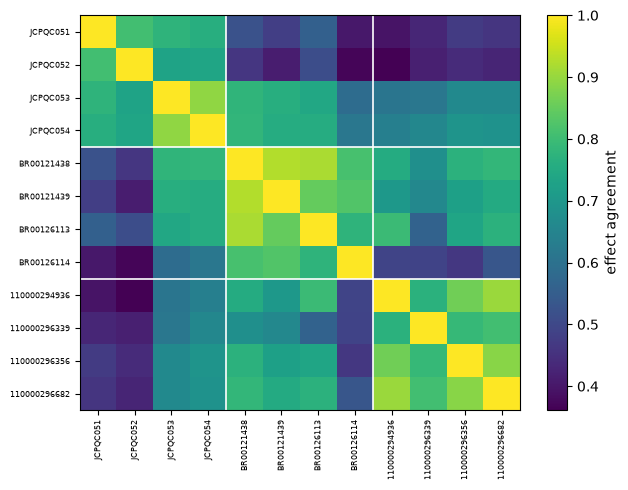

In [17]:
fig, ax = plt.subplots(figsize=(6.5, 5))
mt.pl.setting_agreement(hierarchy, by="Metadata_Source", ax=ax)
fig.tight_layout()
plt.show()

## Summary

- Backed mode saves memory at the cost of speed, and the numbers are identical either way.
- "Site" is ambiguous in this field. JUMP's source is a laboratory; CellProfiler's
  `Metadata_Site` is a field of view.
- A JUMP plate needs its annotation joined before analysis; `read_jump` does that.
- Judge a correction by the question your screen asks. On this data almost every batch
  metric favored a correction that removed the biological signal.
- Reproducibility has levels. `tl.transport` separates them, and the gap between two levels
  is more actionable than either value alone. It is an observational measure: it supports
  "this effect did not reproduce at the other site", but not "this effect would have been
  *x* at the other site".

Next: [10. Differential features](10_differential_features.ipynb), on which features
changed and whether their p-values are reliable.